# Switch-Centered Local PH: Time-Course Models, Comparisons, and Moderators

How does local topology evolve over time around real HMM regime switches,
> and how does that compare with matched pseudo-switch anchors?

It then asks whether the time course differs by:
- posterior jump magnitude
- regime stability type
- client valence direction
- therapist valence direction

In [1]:
import json
import warnings
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from patsy import dmatrix, build_design_matrices
from scipy.stats import spearmanr, wilcoxon
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM

warnings.filterwarnings("ignore")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["axes.grid"] = False
plt.rcParams["svg.fonttype"] = "none"

ARTIFACTS_DIR = Path("../artifacts")
CHMM_DIR = ARTIFACTS_DIR / "chmm_8_full_dataset"
PHASE_DIR = ARTIFACTS_DIR / "regime_geometry" / "phase_transitions"

FIG_DIR = PHASE_DIR / "notebook_figures"
TAB_DIR = PHASE_DIR / "notebook_tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("CHMM_DIR exists:", CHMM_DIR.exists())
print("PHASE_DIR exists:", PHASE_DIR.exists())

TOPO_FEATURES = [
    "total_persistence_h1",
    "betti_h1_auc",
    "persistence_entropy_h1",
]

PRIMARY_WINDOW_LABELS = [
    "far_before",
    "near_before",
    "transition",
    "near_after",
    "far_after",
]

CHMM_DIR exists: True
PHASE_DIR exists: True


## 1. Load Outputs
If the phase-transition outputs are missing, run `make phase-transitions` first.

In [2]:
rolling_path = PHASE_DIR / "rolling_ph_timeseries.csv"
aligned_path = PHASE_DIR / "switch_aligned_rolling_ph.csv"
combined_aligned_path = PHASE_DIR / "combined_aligned_rolling_ph.csv"
switch_path = PHASE_DIR / "switch_local_segment_ph.csv"
delta_path = PHASE_DIR / "switch_reorganization_delta.csv"
jump_assoc_path = PHASE_DIR / "switch_jump_association.csv"
transition_summary_path = PHASE_DIR / "switch_transition_type_reorganization.csv"
matched_anchors_path = PHASE_DIR / "matched_real_pseudo_anchors.csv"

required = [combined_aligned_path, switch_path]
missing = [p for p in required if not p.exists()]
if missing:
    print("Missing core phase-transition outputs:")
    for p in missing:
        print(" -", p)
    print("Run `make phase-transitions` first.")
    df_aligned_raw = pd.DataFrame()
    df_switch_raw = pd.DataFrame()
    df_rolling_raw = pd.DataFrame()
    df_matched_anchors = pd.DataFrame()
else:
    df_aligned_raw = pd.read_csv(combined_aligned_path)
    df_switch_raw = pd.read_csv(switch_path)
    df_rolling_raw = pd.read_csv(rolling_path) if rolling_path.exists() else pd.DataFrame()
    df_matched_anchors = pd.read_csv(matched_anchors_path) if matched_anchors_path.exists() else pd.DataFrame()
    print("Loaded aligned rows (real+pseudo):", df_aligned_raw.shape)
    print("Loaded switch rows:", df_switch_raw.shape)
    print("Loaded rolling rows:", df_rolling_raw.shape)
    print("Loaded matched anchor rows:", df_matched_anchors.shape)

display(df_aligned_raw.head(3) if not df_aligned_raw.empty else pd.DataFrame())


Loaded aligned rows (real+pseudo): (1852247, 24)
Loaded switch rows: (77560, 15)
Loaded rolling rows: (65478, 14)
Loaded matched anchor rows: (76181, 4)


,session_id,dyad_id,time_idx,time_sec,window_sec,step_sec,metric,m,tau_sec,n_points,...,rel_time_idx,rel_time_sec,switch_index,switch_time_idx,from_state,to_state,transition_type,posterior_jump_l2,phase,anchor_kind
0,001_A,1,15,15.0,30.0,5.0,euclidean,10,1.0,27.0,...,9,9.0,0,6,0,2,0->2,1.280034,after,real
1,001_A,1,20,20.0,30.0,5.0,euclidean,10,1.0,31.0,...,14,14.0,0,6,0,2,0->2,1.280034,after,real
2,001_A,1,25,25.0,30.0,5.0,euclidean,10,1.0,31.0,...,19,19.0,0,6,0,2,0->2,1.280034,after,real


## 2. Build Unified Analysis Table
This section creates one analysis-ready table used throughout the notebook.

In [3]:
def _safe_quantile_bins(x: pd.Series, labels=("small", "medium", "large")) -> pd.Series:
    good = x.dropna()
    if good.nunique() < 3 or len(good) < 6:
        return pd.Series(["unknown"] * len(x), index=x.index)

    q1, q2 = good.quantile([1/3, 2/3])

    def _bin(v):
        if pd.isna(v):
            return "unknown"
        if v <= q1:
            return labels[0]
        if v <= q2:
            return labels[1]
        return labels[2]

    return x.map(_bin)

def _compute_run_labels(chmm_dir: Path) -> pd.DataFrame:
    dec_path = chmm_dir / "decoded_sessions.csv"
    if not dec_path.exists():
        return pd.DataFrame()

    dec = pd.read_csv(dec_path)
    path_map = {}
    for _, r in dec.iterrows():
        pf = chmm_dir / r["path_file"]
        if pf.exists():
            path_map[str(r["session_id"])] = np.load(pf).astype(int)

    run_info_rows = []
    for sid, path in path_map.items():
        if len(path) < 2:
            continue
        run_start = 0
        switch_counter = 0
        for t in range(1, len(path)):
            if path[t] != path[t - 1]:
                from_run_len = t - run_start
                run_end = t + 1
                while run_end < len(path) and path[run_end] == path[t]:
                    run_end += 1
                to_run_len = run_end - t
                run_info_rows.append(
                    {
                        "session_id": sid,
                        "switch_index": switch_counter,
                        "from_run_len": int(from_run_len),
                        "to_run_len": int(to_run_len),
                    }
                )
                switch_counter += 1
                run_start = t

    df_runs = pd.DataFrame(run_info_rows)
    if df_runs.empty:
        return df_runs

    persistent_thresh = float(df_runs[["from_run_len", "to_run_len"]].stack().quantile(0.75))
    df_runs["from_persistent"] = df_runs["from_run_len"] >= persistent_thresh
    df_runs["to_persistent"] = df_runs["to_run_len"] >= persistent_thresh

    def stability_type(r):
        if r["from_persistent"] and (not r["to_persistent"]):
            return "out_of_persistent"
        if (not r["from_persistent"]) and r["to_persistent"]:
            return "into_persistent"
        if r["from_persistent"] and r["to_persistent"]:
            return "persistent_to_persistent"
        return "nonpersistent_to_nonpersistent"

    df_runs["regime_stability_type"] = df_runs.apply(stability_type, axis=1)
    return df_runs[
        [
            "session_id",
            "switch_index",
            "from_run_len",
            "to_run_len",
            "regime_stability_type",
        ]
    ]


def _state_valence_scores(model_json: Path) -> tuple[np.ndarray | None, np.ndarray | None]:
    if not model_json.exists():
        return None, None

    params = json.loads(model_json.read_text())
    pT = np.asarray(params.get("pT"), dtype=float)
    pC = np.asarray(params.get("pC"), dtype=float)

    therapist_score = None
    client_score = None

    # Assumes emission code ordering [negative, neutral, positive].
    if pT.ndim == 2 and pT.shape[1] == 3:
        therapist_score = pT @ np.array([-1.0, 0.0, 1.0])
    if pC.ndim == 2 and pC.shape[1] == 3:
        client_score = pC @ np.array([-1.0, 0.0, 1.0])

    return therapist_score, client_score


def _valence_direction_label(
    from_state: float,
    to_state: float,
    score: np.ndarray | None,
    threshold: float = 0.1,
    neutral_band: float = 0.25,
) -> str:
    if score is None:
        return "unknown"
    if pd.isna(from_state) or pd.isna(to_state):
        return "unknown"
    if from_state < 0 or to_state < 0:
        return "unknown"

    fr = int(from_state)
    to = int(to_state)
    if fr >= len(score) or to >= len(score):
        return "unknown"

    from_score = float(score[fr])
    to_score = float(score[to])
    dv = to_score - from_score

    # Tiny shifts → flat bucket
    if abs(dv) < threshold:
        return "neutral_or_minimal_change"

    from_is_neutral = abs(from_score) <= neutral_band
    to_is_neutral = abs(to_score) <= neutral_band

    if dv < 0:
        return "toward_more_negative"

    if dv > 0:
        # collapse neutral + positive into one
        return "toward_neutral_or_positive"

    return "neutral_or_minimal_change"

def _phase_window_label(rel_time_sec: float) -> str | None:
    if pd.isna(rel_time_sec):
        return None
    if -30 <= rel_time_sec < -15:
        return "far_before"
    if -15 <= rel_time_sec < -5:
        return "near_before"
    if -5 <= rel_time_sec <= 5:
        return "transition"
    if 5 < rel_time_sec <= 15:
        return "near_after"
    if 15 < rel_time_sec <= 30:
        return "far_after"
    return None


def _add_baseline_centered_features(
    df: pd.DataFrame,
    features: Iterable[str],
    baseline_window=(-15, -5),
) -> pd.DataFrame:
    out = df.copy()
    lo, hi = baseline_window

    for f in features:
        base_name = f"{f}_baseline_centered"
        base = (
            out[(out["rel_time_sec"] >= lo) & (out["rel_time_sec"] <= hi)]
            .groupby(["session_id", "switch_index", "anchor_kind"], as_index=False)[f]
            .mean()
            .rename(columns={f: f"{f}_baseline"})
        )
        out = out.merge(base, on=["session_id", "switch_index", "anchor_kind"], how="left")
        out[base_name] = out[f] - out[f"{f}_baseline"]

    return out

def build_analysis_table(
    df_aligned: pd.DataFrame,
    df_switch: pd.DataFrame,
    chmm_dir: Path,
    features: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if df_aligned.empty or df_switch.empty:
        return pd.DataFrame(), pd.DataFrame()

    key_cols = [
        "session_id",
        "switch_index",
        "from_state",
        "to_state",
        "transition_type",
        "posterior_jump_l2",
    ]
    keep_cols = [c for c in key_cols if c in df_switch.columns]
    df_switch_labels = df_switch[keep_cols].drop_duplicates(["session_id", "switch_index"]).copy()
    df_switch_labels["transition_identity"] = df_switch_labels["transition_type"].astype(str)
    df_switch_labels["jump_magnitude_bin"] = _safe_quantile_bins(df_switch_labels["posterior_jump_l2"])

    df_runs = _compute_run_labels(chmm_dir)
    if not df_runs.empty:
        df_switch_labels = df_switch_labels.merge(
            df_runs,
            on=["session_id", "switch_index"],
            how="left",
        )
    else:
        df_switch_labels["regime_stability_type"] = "unknown"
        df_switch_labels["from_run_len"] = np.nan
        df_switch_labels["to_run_len"] = np.nan

    therapist_score, client_score = _state_valence_scores(chmm_dir / "best_model.json")

    df_switch_labels["client_valence_direction"] = df_switch_labels.apply(
        lambda r: _valence_direction_label(
            r.get("from_state", np.nan),
            r.get("to_state", np.nan),
            client_score,
            threshold=0.1,
        ),
        axis=1,
    )
    df_switch_labels["therapist_valence_direction"] = df_switch_labels.apply(
        lambda r: _valence_direction_label(
            r.get("from_state", np.nan),
            r.get("to_state", np.nan),
            therapist_score,
            threshold=0.1,
        ),
        axis=1,
    )

    df_main = df_aligned.merge(
        df_switch_labels[
            [
                "session_id",
                "switch_index",
                "transition_identity",
                "jump_magnitude_bin",
                "regime_stability_type",
                "client_valence_direction",
                "therapist_valence_direction",
                "from_run_len",
                "to_run_len",
            ]
        ],
        on=["session_id", "switch_index"],
        how="left",
    )

    fill_cols = [
        "transition_identity",
        "jump_magnitude_bin",
        "regime_stability_type",
        "client_valence_direction",
        "therapist_valence_direction",
    ]
    for col in fill_cols:
        if col in df_main.columns:
            df_main[col] = df_main[col].fillna("pseudo")

    df_main["phase_window_5"] = df_main["rel_time_sec"].map(_phase_window_label)
    df_main["abs_rel_time_sec"] = df_main["rel_time_sec"].abs()

    if "time_sec" in df_main.columns:
        max_by_session = df_main.groupby("session_id")["time_sec"].transform("max")
        df_main["norm_session_time"] = np.where(max_by_session > 0, df_main["time_sec"] / max_by_session, np.nan)
    else:
        df_main["norm_session_time"] = np.nan

    df_main = _add_baseline_centered_features(df_main, features)
    return df_main, df_switch_labels


if df_aligned_raw.empty or df_switch_raw.empty:
    print("No aligned/switch data available yet.")
    df_main = pd.DataFrame()
    df_switch_labels = pd.DataFrame()
else:
    df_main, df_switch_labels = build_analysis_table(
        df_aligned_raw,
        df_switch_raw,
        CHMM_DIR,
        TOPO_FEATURES,
    )
    print("Built analysis table:", df_main.shape)
    print("Built switch-label table:", df_switch_labels.shape)
    display(df_switch_labels.head(5))
    display(df_main.head(5))



Built analysis table: (1852247, 40)
Built switch-label table: (77560, 13)


,session_id,switch_index,from_state,to_state,transition_type,posterior_jump_l2,transition_identity,jump_magnitude_bin,from_run_len,to_run_len,regime_stability_type,client_valence_direction,therapist_valence_direction
0,001_A,0,0,2,0->2,1.280034,0->2,large,6,2,out_of_persistent,toward_more_negative,toward_neutral_or_positive
1,001_A,1,2,4,2->4,1.112095,2->4,medium,2,1,nonpersistent_to_nonpersistent,toward_neutral_or_positive,neutral_or_minimal_change
2,001_A,2,4,6,4->6,0.041470,4->6,small,1,1,nonpersistent_to_nonpersistent,neutral_or_minimal_change,neutral_or_minimal_change
3,001_A,3,6,4,6->4,0.178276,6->4,small,1,1,nonpersistent_to_nonpersistent,neutral_or_minimal_change,neutral_or_minimal_change
4,001_A,4,4,6,4->6,0.364406,4->6,small,1,1,nonpersistent_to_nonpersistent,neutral_or_minimal_change,neutral_or_minimal_change


,session_id,dyad_id,time_idx,time_sec,window_sec,step_sec,metric,m,tau_sec,n_points,...,to_run_len,phase_window_5,abs_rel_time_sec,norm_session_time,total_persistence_h1_baseline,total_persistence_h1_baseline_centered,betti_h1_auc_baseline,betti_h1_auc_baseline_centered,persistence_entropy_h1_baseline,persistence_entropy_h1_baseline_centered
0,001_A,1,15,15.0,30.0,5.0,euclidean,10,1.0,27.0,...,2,near_after,9.0,0.005597,NaN,NaN,NaN,NaN,NaN,NaN
1,001_A,1,20,20.0,30.0,5.0,euclidean,10,1.0,31.0,...,2,near_after,14.0,0.007463,NaN,NaN,NaN,NaN,NaN,NaN
2,001_A,1,25,25.0,30.0,5.0,euclidean,10,1.0,31.0,...,2,far_after,19.0,0.009328,NaN,NaN,NaN,NaN,NaN,NaN
3,001_A,1,30,30.0,30.0,5.0,euclidean,10,1.0,31.0,...,2,far_after,24.0,0.011194,NaN,NaN,NaN,NaN,NaN,NaN
4,001_A,1,35,35.0,30.0,5.0,euclidean,10,1.0,31.0,...,2,far_after,29.0,0.013060,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Coverage and QC
Before modeling, inspect how much data support exists across sessions, anchors, windows, and moderator groups.

,n_rows,n_sessions,n_real_switches,n_pseudo_switches,n_real_rows,n_pseudo_rows
0,1852247,133,77560,76181,936147,916100


,anchor_kind,rel_time_sec,n_rows
0,pseudo,-30.0,15010
1,pseudo,-29.0,14969
2,pseudo,-28.0,15010
3,pseudo,-27.0,14888
4,pseudo,-26.0,15041
5,pseudo,-25.0,15042
6,pseudo,-24.0,14992
7,pseudo,-23.0,15038
8,pseudo,-22.0,14920
9,pseudo,-21.0,15075


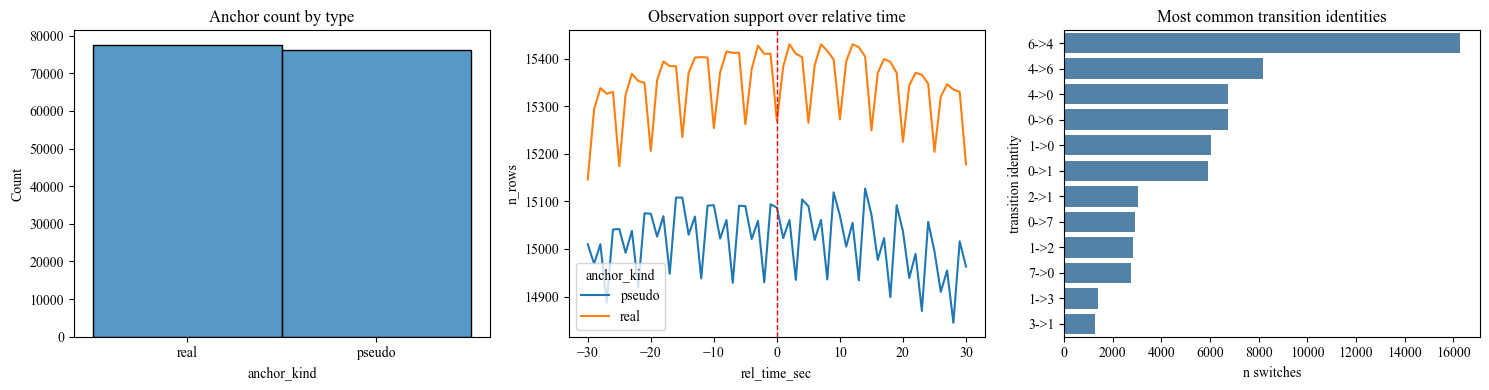

In [4]:
if df_main.empty:
    print("No analysis table available yet.")
else:
    qc_rows = {
        "n_rows": len(df_main),
        "n_sessions": df_main["session_id"].nunique(),
        "n_real_switches": df_main.loc[df_main["anchor_kind"] == "real", ["session_id", "switch_index"]].drop_duplicates().shape[0],
        "n_pseudo_switches": df_main.loc[df_main["anchor_kind"] == "pseudo", ["session_id", "switch_index"]].drop_duplicates().shape[0],
        "n_real_rows": int((df_main["anchor_kind"] == "real").sum()),
        "n_pseudo_rows": int((df_main["anchor_kind"] == "pseudo").sum()),
    }
    display(pd.DataFrame([qc_rows]))

    support = (
        df_main.groupby(["anchor_kind", "rel_time_sec"], as_index=False)
        .size()
        .rename(columns={"size": "n_rows"})
        .sort_values(["anchor_kind", "rel_time_sec"])
    )
    display(support.head(10))
    support.to_csv(TAB_DIR / "time_support_by_anchor_kind.csv", index=False)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    sns.histplot(
        data=df_main.drop_duplicates(["session_id", "switch_index", "anchor_kind"]),
        x="anchor_kind",
        ax=axes[0],
    )
    axes[0].set_title("Anchor count by type")

    sns.lineplot(data=support, x="rel_time_sec", y="n_rows", hue="anchor_kind", ax=axes[1])
    axes[1].axvline(0.0, color="red", linestyle="--", linewidth=1.0)
    axes[1].set_title("Observation support over relative time")

    if "transition_identity" in df_switch_labels.columns and not df_switch_labels.empty:
        top_trans = df_switch_labels["transition_identity"].value_counts().head(12)
        sns.barplot(x=top_trans.values, y=top_trans.index, color="steelblue", ax=axes[2])
        axes[2].set_title("Most common transition identities")
        axes[2].set_xlabel("n switches")
        axes[2].set_ylabel("transition identity")

    plt.tight_layout()
    plt.savefig(FIG_DIR / "qc_overview.svg", format="svg")
    plt.show()

## 4. Helper Functions for Time-Course Modeling and Plotting
The notebook centers the analysis around time-course plots and comparisons.

In [5]:
def _full_rank_design(X: pd.DataFrame, tol: float = 1e-10) -> pd.DataFrame:
    X = X.copy()
    has_const = "const" in X.columns
    const_col = X[["const"]].copy() if has_const else None

    non_const_cols = [c for c in X.columns if c != "const"]
    if len(non_const_cols) > 0:
        Xn = X[non_const_cols]
        keep = Xn.columns[Xn.std(axis=0) > tol]
        Xn = Xn[keep]
        while Xn.shape[1] > 0 and np.linalg.matrix_rank(Xn.to_numpy()) < Xn.shape[1]:
            Xn = Xn.iloc[:, :-1]
    else:
        Xn = pd.DataFrame(index=X.index)

    Xout = pd.concat([const_col, Xn], axis=1) if has_const else Xn
    while Xout.shape[1] > 1 and np.linalg.matrix_rank(Xout.to_numpy()) < Xout.shape[1]:
        if "const" in Xout.columns and Xout.columns[-1] == "const":
            break
        Xout = Xout.iloc[:, :-1]
    return Xout


def summarize_timecourse(
    df: pd.DataFrame,
    feature: str,
    group_col: str,
    min_sessions: int = 8,
) -> pd.DataFrame:
    d = df[["session_id", "rel_time_sec", group_col, feature]].dropna().copy()
    if d.empty:
        return pd.DataFrame()

    session_counts = d.groupby(group_col)["session_id"].nunique()
    keep = session_counts[session_counts >= min_sessions].index
    d = d[d[group_col].isin(keep)].copy()
    if d.empty:
        return pd.DataFrame()

    # Session-level mean at each rel_time first, then across sessions.
    by_session = (
        d.groupby([group_col, "session_id", "rel_time_sec"], as_index=False)[feature]
        .mean()
        .rename(columns={feature: "value"})
    )

    out = (
        by_session.groupby([group_col, "rel_time_sec"], as_index=False)["value"]
        .agg(mean="mean", sd="std", n="count")
        .sort_values([group_col, "rel_time_sec"])
    )
    out["sem"] = out["sd"] / np.sqrt(out["n"].clip(lower=1))
    out["lower"] = out["mean"] - 1.96 * out["sem"]
    out["upper"] = out["mean"] + 1.96 * out["sem"]
    out["feature"] = feature
    return out

def plot_timecourse_summary(
    summary_df: pd.DataFrame,
    group_col: str,
    feature: str,
    title: str,
    out_path: Path | None = None,
    palette: dict | None = None,
):
    if summary_df.empty:
        print(f"No summary data for {feature} by {group_col}")
        return

    sub = summary_df[summary_df["feature"] == feature].copy()
    if sub.empty:
        print(f"No rows for {feature} by {group_col}")
        return

    plt.figure(figsize=(10, 5))
    groups = list(sub[group_col].dropna().unique())
    for g in groups:
        dg = sub[sub[group_col] == g].sort_values("rel_time_sec")
        color = palette.get(g) if palette is not None else None
        plt.plot(dg["rel_time_sec"], dg["mean"], linewidth=2, label=str(g), color=color)
        plt.fill_between(dg["rel_time_sec"], dg["lower"], dg["upper"], alpha=0.18, color=color)

    plt.axvline(0.0, color="red", linestyle="--", linewidth=1.0)
    plt.title(title)
    plt.xlabel("Time relative to switch (sec)")
    plt.ylabel(feature)
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    if out_path is not None:
        plt.savefig(out_path, format="svg")
    plt.show()

def plot_timecourse_grid(
    df: pd.DataFrame,
    features: list[str],
    group_col: str,
    out_name: str,
    min_sessions: int = 8,
    palette: dict | None = None,
):
    summary_rows = []
    for f in features:
        s = summarize_timecourse(df, f, group_col, min_sessions=min_sessions)
        if not s.empty:
            summary_rows.append(s)

    if not summary_rows:
        print(f"No summary rows available for group column {group_col}")
        return pd.DataFrame()

    df_sum = pd.concat(summary_rows, ignore_index=True)
    df_sum.to_csv(TAB_DIR / f"{out_name}_summary.csv", index=False)

    n_feat = len(features)
    fig, axes = plt.subplots(n_feat, 1, figsize=(11, max(4, 3.4 * n_feat)), sharex=True)
    if n_feat == 1:
        axes = [axes]

    for ax, f in zip(axes, features):
        sub = df_sum[df_sum["feature"] == f].copy()
        for g in sub[group_col].dropna().unique():
            dg = sub[sub[group_col] == g].sort_values("rel_time_sec")
            color = palette.get(g) if palette is not None else None
            ax.plot(dg["rel_time_sec"], dg["mean"], linewidth=2, label=str(g), color=color)
            ax.fill_between(dg["rel_time_sec"], dg["lower"], dg["upper"], alpha=0.18, color=color)
        ax.axvline(0.0, color="red", linestyle="--", linewidth=1.0)
        ax.set_title(f"{f} by {group_col}")
        ax.set_ylabel(f)
        ax.legend(loc="best", fontsize=8)

    axes[-1].set_xlabel("Time relative to switch (sec)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{out_name}.svg", format="svg")
    plt.show()
    return df_sum

def fit_mixed_spline_interaction(
    df: pd.DataFrame,
    feature: str,
    spline_df_candidates=(5, 4, 3),
):
    d = df[["session_id", "rel_time_sec", "anchor_kind", feature]].dropna().copy()
    if len(d) < 60 or d["session_id"].nunique() < 4 or d["anchor_kind"].nunique() < 2:
        return None, None

    d["is_real"] = (d["anchor_kind"] == "real").astype(float)
    last_err = None

    for sdf in spline_df_candidates:
        try:
            X_basis = dmatrix(
                f"bs(rel_time_sec, df={sdf}, degree=3, include_intercept=False)",
                d,
                return_type="dataframe",
            )
            design_info = X_basis.design_info
            X_main = X_basis.copy()
            X_main["is_real"] = d["is_real"].to_numpy()
            for c in X_basis.columns:
                X_main[f"{c}:is_real"] = X_basis[c].to_numpy() * d["is_real"].to_numpy()
            X = sm.add_constant(X_main, has_constant="add")
            X = _full_rank_design(X)
            if "const" not in X.columns:
                X = sm.add_constant(X, has_constant="add")
            if X.shape[1] < 2:
                continue

            try:
                model = MixedLM(endog=d[feature], exog=X, groups=d["session_id"])
                fit = model.fit(reml=False, method="lbfgs", maxiter=300)
                return d, {
                    "fit": fit,
                    "model_type": "MixedLM_time_x_anchor",
                    "spline_df": int(sdf),
                    "X_cols": list(X.columns),
                    "design_info": design_info,
                }
            except Exception as e:
                last_err = e

            try:
                fit = sm.OLS(d[feature], X).fit()
                print(f"Fallback to OLS interaction spline for {feature} (spline_df={sdf}) due to MixedLM failure.")
                return d, {
                    "fit": fit,
                    "model_type": "OLS_time_x_anchor_fallback",
                    "spline_df": int(sdf),
                    "X_cols": list(X.columns),
                    "design_info": design_info,
                }
            except Exception as e2:
                last_err = e2
        except Exception as e:
            last_err = e

    print(f"Skipping {feature}: unable to fit time x anchor model ({type(last_err).__name__}: {last_err})")
    return None, None


def predict_anchor_curves(fit_bundle, t_min: float, t_max: float, n: int = 200) -> pd.DataFrame:
    fit = fit_bundle["fit"]
    x_cols = fit_bundle["X_cols"]
    design_info = fit_bundle["design_info"]

    rows = []
    for anchor_kind, is_real in [("pseudo", 0.0), ("real", 1.0)]:
        grid = pd.DataFrame({"rel_time_sec": np.linspace(t_min, t_max, n)})
        Xg_basis = build_design_matrices([design_info], grid, return_type="dataframe")[0]
        Xg_main = Xg_basis.copy()
        Xg_main["is_real"] = is_real
        for c in Xg_basis.columns:
            Xg_main[f"{c}:is_real"] = Xg_basis[c].to_numpy() * is_real
        Xg = sm.add_constant(Xg_main, has_constant="add")
        for c in x_cols:
            if c not in Xg.columns:
                Xg[c] = 0.0
        Xg = Xg[x_cols]
        if "const" not in Xg.columns:
            Xg = sm.add_constant(Xg, has_constant="add")
        grid["pred"] = fit.predict(exog=Xg)
        grid["anchor_kind"] = anchor_kind
        rows.append(grid)

    out = pd.concat(rows, ignore_index=True)
    return out


def make_difference_curve(pred_df: pd.DataFrame) -> pd.DataFrame:
    if pred_df.empty:
        return pd.DataFrame()
    wide = pred_df.pivot_table(index="rel_time_sec", columns="anchor_kind", values="pred").reset_index()
    if "real" not in wide.columns or "pseudo" not in wide.columns:
        return pd.DataFrame()
    wide["real_minus_pseudo"] = wide["real"] - wide["pseudo"]
    return wide.sort_values("rel_time_sec")


def summarize_window_effects(
    df: pd.DataFrame,
    feature: str,
    window_col: str = "phase_window_5",
) -> pd.DataFrame:
    d = df[["session_id", "switch_index", "anchor_kind", window_col, feature]].dropna().copy()
    if d.empty:
        return pd.DataFrame()

    sw = (
        d.groupby(["session_id", "switch_index", "anchor_kind", window_col], as_index=False)[feature]
        .mean()
        .rename(columns={feature: "value"})
    )
    out = (
        sw.groupby(["anchor_kind", window_col], as_index=False)["value"]
        .agg(mean="mean", sd="std", n="count")
    )
    out["sem"] = out["sd"] / np.sqrt(out["n"].clip(lower=1))
    out["lower"] = out["mean"] - 1.96 * out["sem"]
    out["upper"] = out["mean"] + 1.96 * out["sem"]
    out["feature"] = feature
    return out

def add_baseline_normalized(df, features, baseline_window=(-20, -10)):
    df_out = df.copy()

    baseline_mask = (
        (df_out["rel_time_sec"] >= baseline_window[0]) &
        (df_out["rel_time_sec"] <= baseline_window[1])
    )

    baseline_df = df_out.loc[baseline_mask, ["session_id", "switch_index", *features]].copy()

    if baseline_df.empty:
        print("No rows found in baseline window.")
        for f in features:
            df_out[f"{f}_baseline"] = np.nan
            df_out[f"{f}_delta"] = np.nan
        return df_out

    baseline = (
        baseline_df
        .groupby(["session_id", "switch_index"], as_index=False)[list(features)]
        .mean()
    )

    baseline_cols = {}
    for f in features:
        baseline_cols[f] = f"{f}_baseline"
    baseline = baseline.rename(columns=baseline_cols)

    df_out = df_out.merge(baseline, on=["session_id", "switch_index"], how="left")

    for f in features:
        base_col = f"{f}_baseline"
        if base_col not in df_out.columns:
            df_out[base_col] = np.nan
        df_out[f"{f}_delta"] = df_out[f] - df_out[base_col]

    return df_out


## 5. Primary Descriptive Time-Course: Real vs Pseudo
This is the main descriptive figure set for the phase-transition story.

For each topology feature, we show the mean trajectory over relative time for real switches and pseudo anchors, with session-level uncertainty bands.

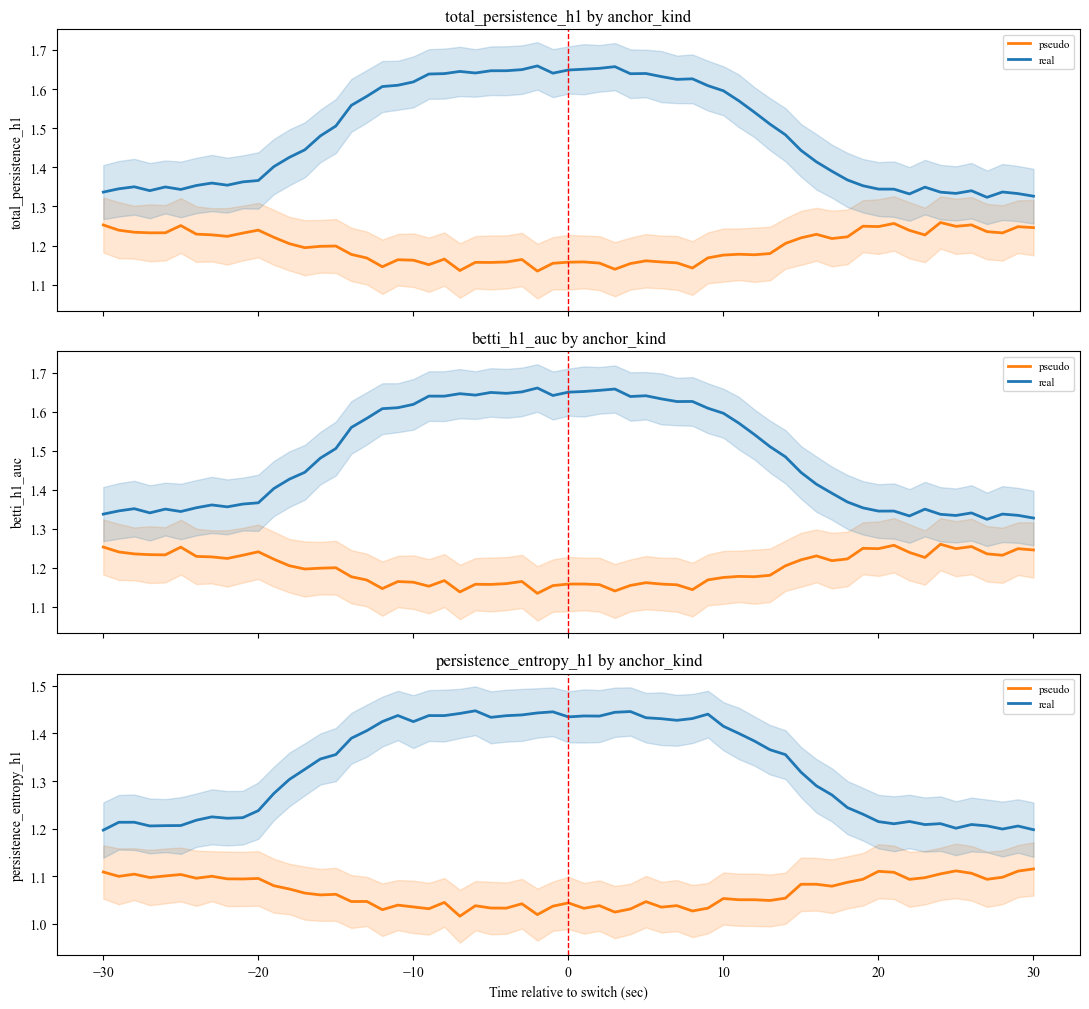

,anchor_kind,rel_time_sec,mean,sd,n,sem,lower,upper,feature
0,pseudo,-30.0,1.252572,0.413432,132,0.035985,1.182042,1.323101,total_persistence_h1
1,pseudo,-29.0,1.239179,0.420214,132,0.036575,1.167492,1.310866,total_persistence_h1
2,pseudo,-28.0,1.233985,0.396218,132,0.034486,1.166392,1.301578,total_persistence_h1
3,pseudo,-27.0,1.232483,0.426524,132,0.037124,1.159720,1.305246,total_persistence_h1
4,pseudo,-26.0,1.232508,0.414984,132,0.036120,1.161713,1.303303,total_persistence_h1
5,pseudo,-25.0,1.251011,0.411833,132,0.035845,1.180754,1.321268,total_persistence_h1
6,pseudo,-24.0,1.229117,0.416693,132,0.036268,1.158031,1.300203,total_persistence_h1
7,pseudo,-23.0,1.227294,0.399106,132,0.034738,1.159208,1.295380,total_persistence_h1
8,pseudo,-22.0,1.223479,0.423517,132,0.036862,1.151229,1.295729,total_persistence_h1
9,pseudo,-21.0,1.231834,0.410785,132,0.035754,1.161756,1.301912,total_persistence_h1


In [6]:
if df_main.empty:
    print("No analysis table available yet.")
else:
    primary_palette = {"real": "tab:blue", "pseudo": "tab:orange"}
    df_primary_sum = plot_timecourse_grid(
        df_main,
        TOPO_FEATURES,
        group_col="anchor_kind",
        out_name="primary_real_vs_pseudo_timecourses",
        min_sessions=8,
        palette=primary_palette,
    )
    display(df_primary_sum.head(10) if not df_primary_sum.empty else pd.DataFrame())


## 6. Primary Inferential Time-Course Model
Main model for each feature:

\[
\text{Topo}_{it} \sim f(\text{rel_time_sec}) * \text{anchor_kind} + (1 \mid \text{session})
\]
This directly tests whether the time course differs for real versus pseudo anchors.


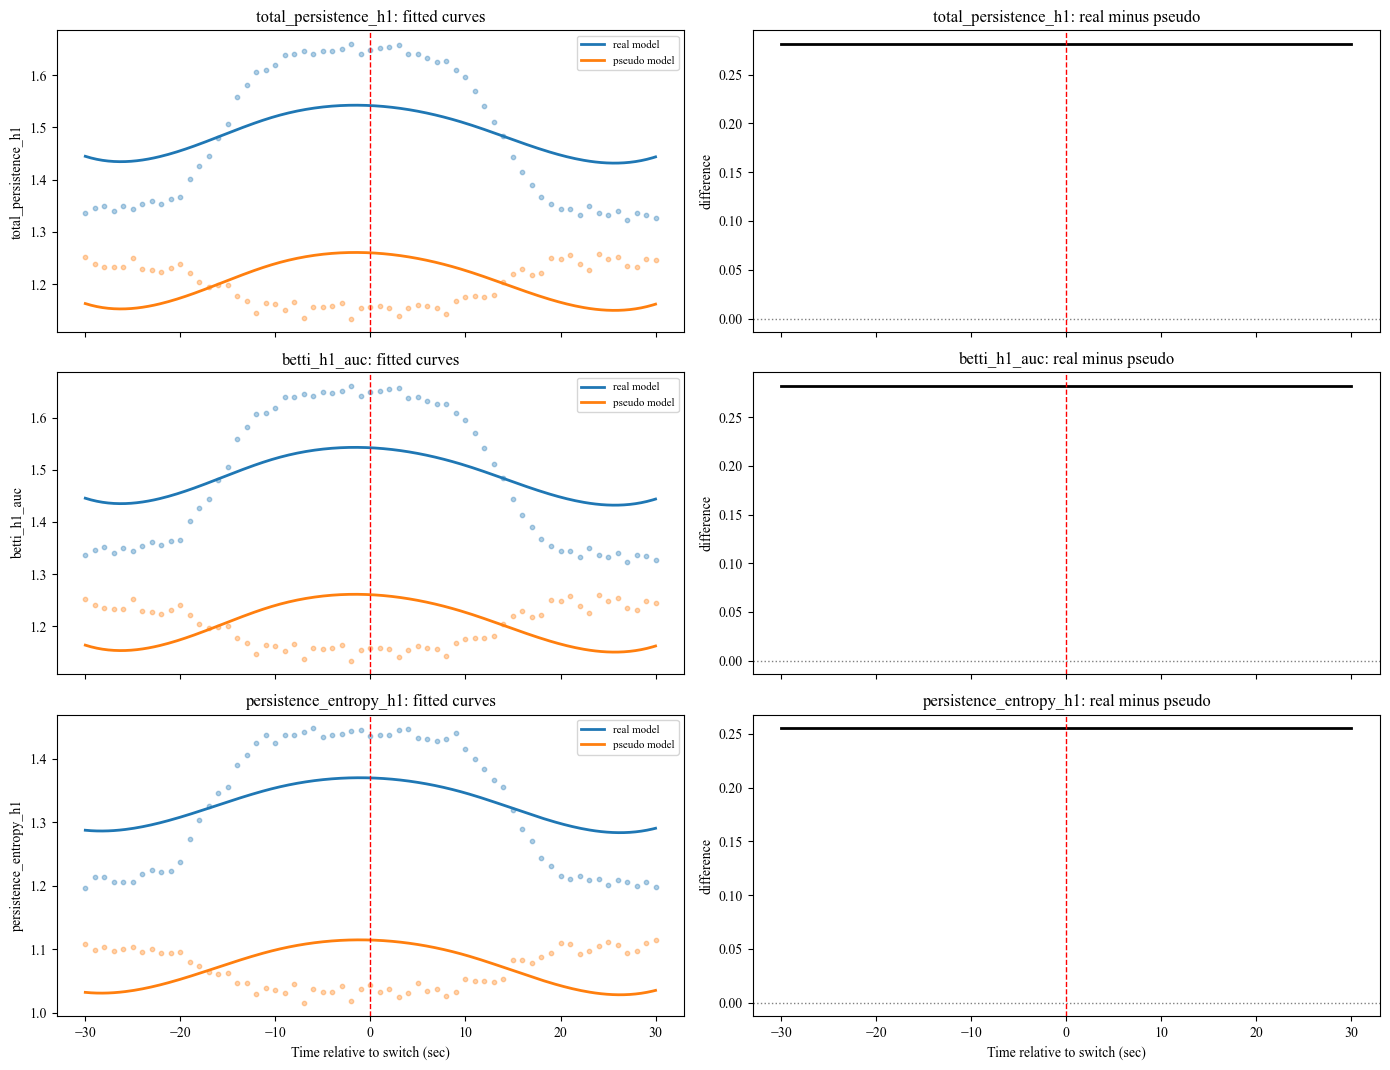

,feature,model_type,spline_df_used,n_obs,n_sessions,aic,bic,llf
0,total_persistence_h1,MixedLM_time_x_anchor,5,1852247,133,5.539926e+06,5.540038e+06,-2.769954e+06
1,betti_h1_auc,MixedLM_time_x_anchor,5,1852247,133,5.550407e+06,5.550519e+06,-2.775194e+06
2,persistence_entropy_h1,MixedLM_time_x_anchor,5,1852247,133,4.555294e+06,4.555406e+06,-2.277638e+06


In [22]:
if df_main.empty:
    print("No analysis table available yet.")
    df_primary_model = pd.DataFrame()
else:
    model_rows = []
    model_fits = {}
    diff_rows = []

    n_feat = len(TOPO_FEATURES)
    fig, axes = plt.subplots(n_feat, 2, figsize=(14, max(4, 3.6 * n_feat)), sharex="col")
    if n_feat == 1:
        axes = np.array([axes])

    for i, f in enumerate(TOPO_FEATURES):
        d, fit_bundle = fit_mixed_spline_interaction(df_main, f, spline_df_candidates=(5, 4, 3))
        if fit_bundle is None:
            continue

        model_fits[f] = (d, fit_bundle)
        fit = fit_bundle["fit"]
        model_rows.append(
            {
                "feature": f,
                "model_type": fit_bundle["model_type"],
                "spline_df_used": fit_bundle["spline_df"],
                "n_obs": int(len(d)),
                "n_sessions": int(d["session_id"].nunique()),
                "aic": float(getattr(fit, "aic", np.nan)),
                "bic": float(getattr(fit, "bic", np.nan)),
                "llf": float(getattr(fit, "llf", np.nan)),
            }
        )

        tmin, tmax = d["rel_time_sec"].min(), d["rel_time_sec"].max()
        pred = predict_anchor_curves(fit_bundle, tmin, tmax, n=200)
        pred["feature"] = f
        pred.to_csv(TAB_DIR / f"predicted_curves_{f}.csv", index=False)

        avg = summarize_timecourse(df_main, f, "anchor_kind", min_sessions=8)
        left_ax = axes[i, 0]
        for kind, color in [("real", "tab:blue"), ("pseudo", "tab:orange")]:
            dg = pred[pred["anchor_kind"] == kind]
            left_ax.plot(dg["rel_time_sec"], dg["pred"], color=color, linewidth=2, label=f"{kind} model")
            ds = avg[(avg["feature"] == f) & (avg["anchor_kind"] == kind)]
            if not ds.empty:
                left_ax.scatter(ds["rel_time_sec"], ds["mean"], s=10, alpha=0.35, color=color)
        left_ax.axvline(0.0, color="red", linestyle="--", linewidth=1.0)
        left_ax.set_title(f"{f}: fitted curves")
        left_ax.set_ylabel(f)
        left_ax.legend(loc="best", fontsize=8)

        diff = make_difference_curve(pred)
        if not diff.empty:
            diff["feature"] = f
            diff_rows.append(diff)
            right_ax = axes[i, 1]
            right_ax.plot(diff["rel_time_sec"], diff["real_minus_pseudo"], color="black", linewidth=2)
            right_ax.axhline(0.0, color="gray", linestyle=":", linewidth=1.0)
            right_ax.axvline(0.0, color="red", linestyle="--", linewidth=1.0)
            right_ax.set_title(f"{f}: real minus pseudo")
            right_ax.set_ylabel("difference")

    axes[-1, 0].set_xlabel("Time relative to switch (sec)")
    axes[-1, 1].set_xlabel("Time relative to switch (sec)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "primary_timecourse_models_and_difference_curves.svg", format="svg")
    plt.show()

    df_primary_model = pd.DataFrame(model_rows)
    df_primary_diff = pd.concat(diff_rows, ignore_index=True) if diff_rows else pd.DataFrame()

    display(df_primary_model)
    if not df_primary_model.empty:
        df_primary_model.to_csv(TAB_DIR / "primary_time_x_anchor_model_summary.csv", index=False)
    if not df_primary_diff.empty:
        df_primary_diff.to_csv(TAB_DIR / "primary_real_minus_pseudo_difference_curves.csv", index=False)



## 7. Windowed and Phase-Based Summaries
Continuous time-course plots are the main result. This section compresses those trajectories into broader windows for easier interpretation. We keep both the original three-phase coding and a five-window view.

,anchor_kind,phase_window_5,mean,sd,n,sem,lower,upper,feature
0,pseudo,far_after,1.326811,1.055181,75028,0.003852,1.319261,1.334362,total_persistence_h1
1,pseudo,far_before,1.315214,1.048661,75225,0.003823,1.307720,1.322708,total_persistence_h1
2,pseudo,near_after,1.258445,1.064662,75364,0.003878,1.250844,1.266046,total_persistence_h1
3,pseudo,near_before,1.245400,1.066051,75372,0.003883,1.237789,1.253011,total_persistence_h1
4,pseudo,transition,1.234914,1.053258,75398,0.003836,1.227396,1.242432,total_persistence_h1
5,real,far_after,1.441681,1.062646,76757,0.003836,1.434163,1.449199,total_persistence_h1
6,real,far_before,1.464560,1.069756,76723,0.003862,1.456990,1.472130,total_persistence_h1
7,real,near_after,1.639313,1.116429,77003,0.004023,1.631428,1.647199,total_persistence_h1
8,real,near_before,1.676936,1.114088,76964,0.004016,1.669065,1.684807,total_persistence_h1
9,real,transition,1.715681,1.089357,77045,0.003925,1.707988,1.723373,total_persistence_h1


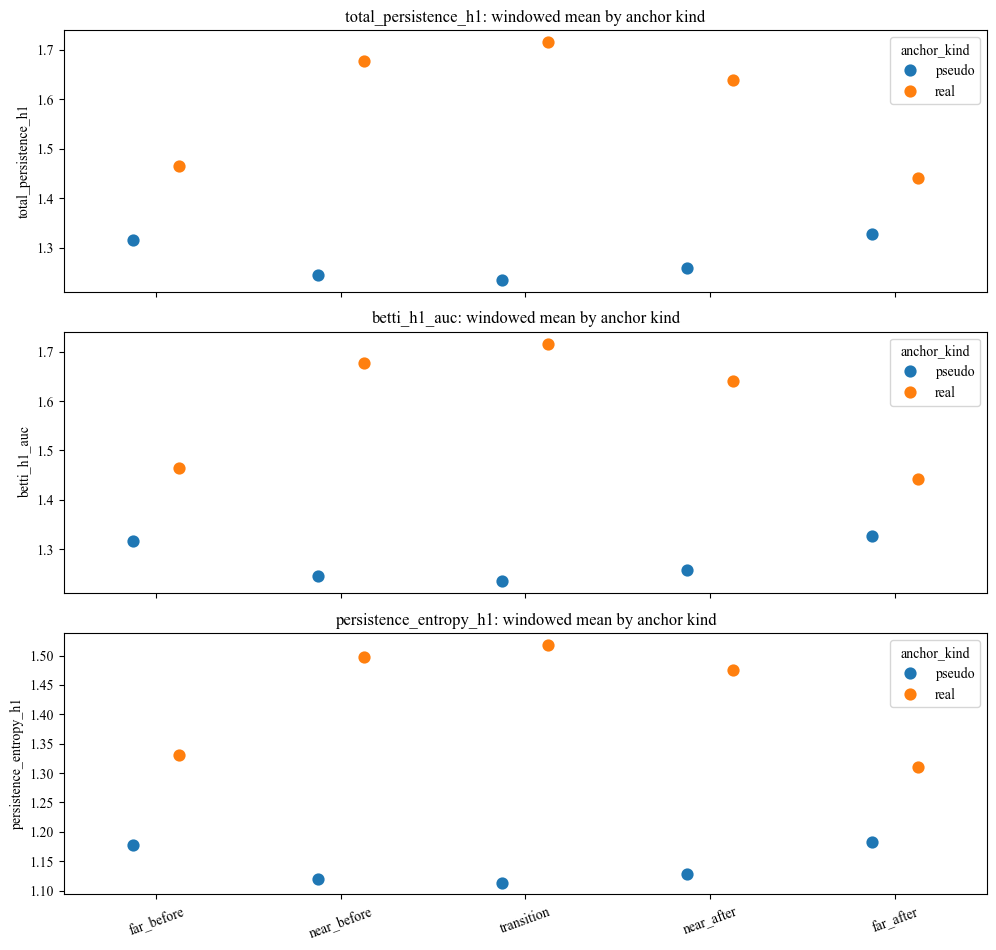

,feature,anchor_kind,contrast,n_switches,mean_delta,median_delta,wilcoxon_stat,wilcoxon_p,mixed_lm_t,mixed_lm_p
0,total_persistence_h1,real,during_minus_before,76740,0.165538,0.149648,1.198882e+09,0.000000e+00,21.777327,3.806398e-105
1,total_persistence_h1,real,after_minus_before,76466,-0.030299,-0.021491,1.422308e+09,4.055324e-10,-5.096910,3.452418e-07
2,total_persistence_h1,real,after_minus_during,76771,-0.195126,-0.168688,1.154158e+09,0.000000e+00,-25.961696,1.341614e-148
3,total_persistence_h1,pseudo,during_minus_before,75040,-0.052814,-0.031974,1.262773e+09,1.849044e-71,-11.191372,4.494250e-29
4,total_persistence_h1,pseudo,after_minus_before,74688,0.010040,0.000005,1.362223e+09,1.490351e-02,2.338097,1.938223e-02
5,total_persistence_h1,pseudo,after_minus_during,75046,0.062967,0.044675,1.234152e+09,4.374267e-110,14.967466,1.197991e-50
6,total_persistence_h1,real,jump_vs_after_before_delta,76466,NaN,NaN,-2.860700e-03,4.289187e-01,NaN,NaN
7,betti_h1_auc,real,during_minus_before,76740,0.165546,0.146884,1.194293e+09,0.000000e+00,21.878666,4.147958e-106
8,betti_h1_auc,real,after_minus_before,76466,-0.030407,-0.021012,1.420211e+09,5.335861e-10,-5.103384,3.336324e-07
9,betti_h1_auc,real,after_minus_during,76771,-0.195227,-0.169524,1.148638e+09,0.000000e+00,-26.028107,2.381114e-149


In [23]:
if df_main.empty:
    print("No analysis table available yet.")
else:
    window_rows = []
    for f in TOPO_FEATURES:
        ws = summarize_window_effects(df_main, f, window_col="phase_window_5")
        if not ws.empty:
            window_rows.append(ws)

    df_window_summary = pd.concat(window_rows, ignore_index=True) if window_rows else pd.DataFrame()
    display(df_window_summary.head(12) if not df_window_summary.empty else pd.DataFrame())
    if not df_window_summary.empty:
        df_window_summary.to_csv(TAB_DIR / "windowed_timecourse_summary.csv", index=False)

        n_feat = len(TOPO_FEATURES)
        fig, axes = plt.subplots(n_feat, 1, figsize=(10, max(4, 3.2 * n_feat)), sharex=True)
        if n_feat == 1:
            axes = [axes]

        for ax, f in zip(axes, TOPO_FEATURES):
            sub = df_window_summary[df_window_summary["feature"] == f].copy()
            sub["phase_window_5"] = pd.Categorical(sub["phase_window_5"], categories=PRIMARY_WINDOW_LABELS, ordered=True)
            sub = sub.sort_values(["phase_window_5", "anchor_kind"])
            sns.pointplot(
                data=sub,
                x="phase_window_5",
                y="mean",
                hue="anchor_kind",
                dodge=0.25,
                join=False,
                errorbar=None,
                ax=ax,
            )
            ax.set_title(f"{f}: windowed mean by anchor kind")
            ax.set_ylabel(f)
            ax.set_xlabel("")
            ax.tick_params(axis="x", rotation=20)

        plt.tight_layout()
        plt.savefig(FIG_DIR / "windowed_real_vs_pseudo_summary.svg", format="svg")
        plt.show()

    # Original before/during/after contrasts with real vs pseudo kept for continuity.
    phase_summary_rows = []
    for f in TOPO_FEATURES:
        d = df_main[["session_id", "switch_index", "anchor_kind", "phase", "posterior_jump_l2", f]].dropna(subset=[f, "phase"]).copy()
        if d.empty:
            continue

        sw = d.groupby(["session_id", "switch_index", "anchor_kind", "phase"], as_index=False)[f].mean()
        wide = sw.pivot_table(index=["session_id", "switch_index", "anchor_kind"], columns="phase", values=f).reset_index()
        jumps = d[d["anchor_kind"] == "real"][["session_id", "switch_index", "posterior_jump_l2"]].drop_duplicates()
        wide = wide.merge(jumps, on=["session_id", "switch_index"], how="left")

        for kind in ["real", "pseudo"]:
            kind_wide = wide[wide["anchor_kind"] == kind]
            for contrast_name, c1, c2 in [
                ("during_minus_before", "before", "during"),
                ("after_minus_before", "before", "after"),
                ("after_minus_during", "during", "after"),
            ]:
                if c1 in kind_wide.columns and c2 in kind_wide.columns:
                    delta_df = kind_wide[[c1, c2, "session_id"]].dropna()
                    delta = delta_df[c2] - delta_df[c1]
                    if len(delta) < 8:
                        continue
                    w_stat, w_p = wilcoxon(delta)
                    try:
                        md = MixedLM.from_formula(
                            "delta ~ 1",
                            data=pd.DataFrame({"delta": delta, "session_id": delta_df["session_id"].to_numpy()}),
                            groups="session_id",
                        ).fit(reml=False)
                        mixed_t = float(md.tvalues.iloc[0])
                        mixed_p = float(md.pvalues.iloc[0])
                    except Exception:
                        mixed_t = np.nan
                        mixed_p = np.nan

                    phase_summary_rows.append(
                        {
                            "feature": f,
                            "anchor_kind": kind,
                            "contrast": contrast_name,
                            "n_switches": int(len(delta)),
                            "mean_delta": float(np.mean(delta)),
                            "median_delta": float(np.median(delta)),
                            "wilcoxon_stat": float(w_stat),
                            "wilcoxon_p": float(w_p),
                            "mixed_lm_t": mixed_t,
                            "mixed_lm_p": mixed_p,
                        }
                    )

        real_wide = wide[wide["anchor_kind"] == "real"]
        if "before" in real_wide.columns and "after" in real_wide.columns:
            dd = real_wide[["posterior_jump_l2", "before", "after"]].dropna().copy()
            if len(dd) >= 8:
                dd["delta_after_minus_before"] = dd["after"] - dd["before"]
                r, p = spearmanr(dd["posterior_jump_l2"], dd["delta_after_minus_before"])
                phase_summary_rows.append(
                    {
                        "feature": f,
                        "anchor_kind": "real",
                        "contrast": "jump_vs_after_before_delta",
                        "n_switches": int(len(dd)),
                        "mean_delta": np.nan,
                        "median_delta": np.nan,
                        "wilcoxon_stat": float(r),
                        "wilcoxon_p": float(p),
                        "mixed_lm_t": np.nan,
                        "mixed_lm_p": np.nan,
                    }
                )

    df_phase_stats = pd.DataFrame(phase_summary_rows) if phase_summary_rows else pd.DataFrame()
    display(df_phase_stats)
    if not df_phase_stats.empty:
        df_phase_stats.to_csv(TAB_DIR / "phase_contrast_and_jump_stats.csv", index=False)


## 8. Moderator Time Courses: Jump Magnitude and Regime Stability
These analyses stay secondary to the main real-vs-pseudo comparison.
To reduce clutter, these moderator plots are shown for **real switches only**.

,session_id,dyad_id,time_idx,time_sec,window_sec,step_sec,metric,m,tau_sec,n_points,...,to_run_len,phase_window_5,abs_rel_time_sec,norm_session_time,total_persistence_h1_baseline,total_persistence_h1_baseline_centered,betti_h1_auc_baseline,betti_h1_auc_baseline_centered,persistence_entropy_h1_baseline,persistence_entropy_h1_baseline_centered
0,001_A,1,15,15.0,30.0,5.0,euclidean,10,1.0,27.0,...,2,near_after,9.0,0.005597,NaN,NaN,NaN,NaN,NaN,NaN
1,001_A,1,20,20.0,30.0,5.0,euclidean,10,1.0,31.0,...,2,near_after,14.0,0.007463,NaN,NaN,NaN,NaN,NaN,NaN
2,001_A,1,25,25.0,30.0,5.0,euclidean,10,1.0,31.0,...,2,far_after,19.0,0.009328,NaN,NaN,NaN,NaN,NaN,NaN


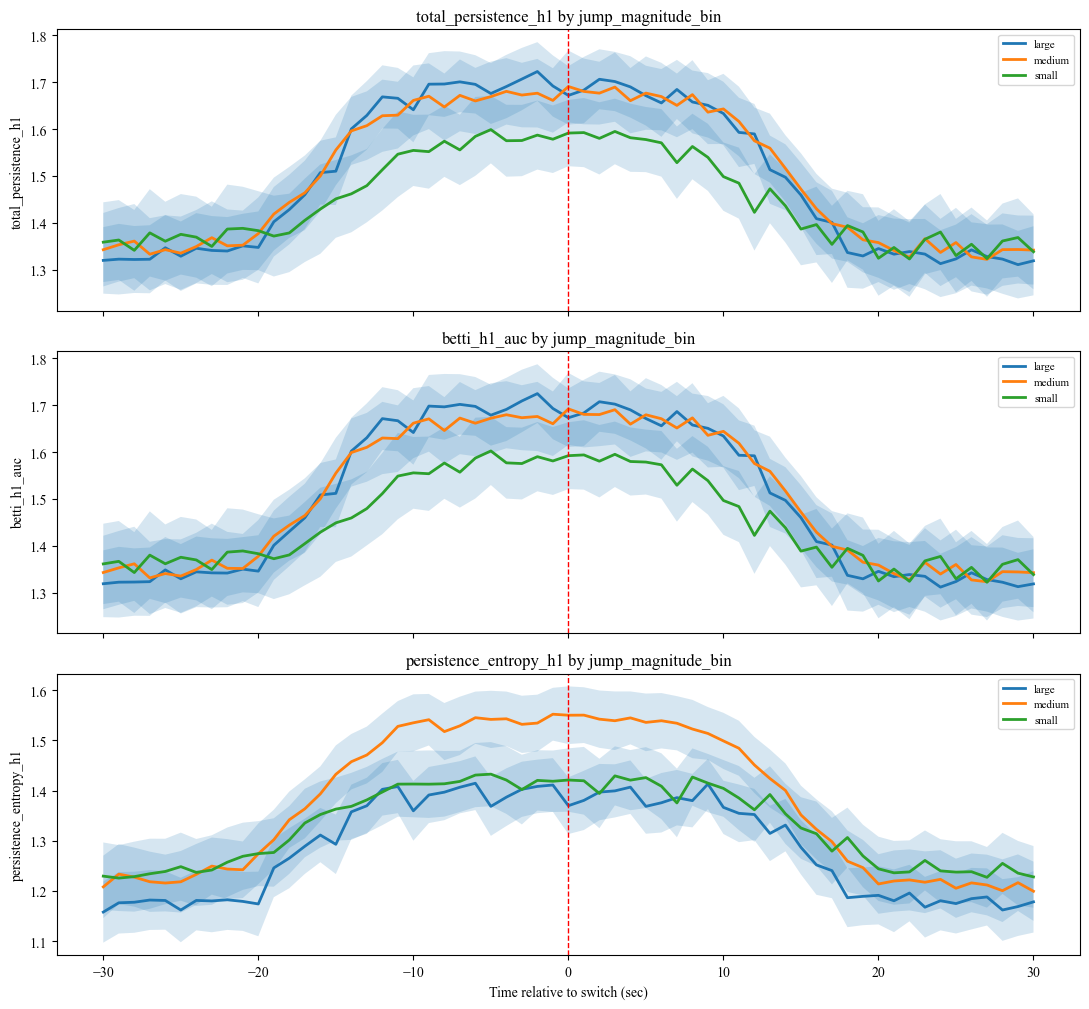

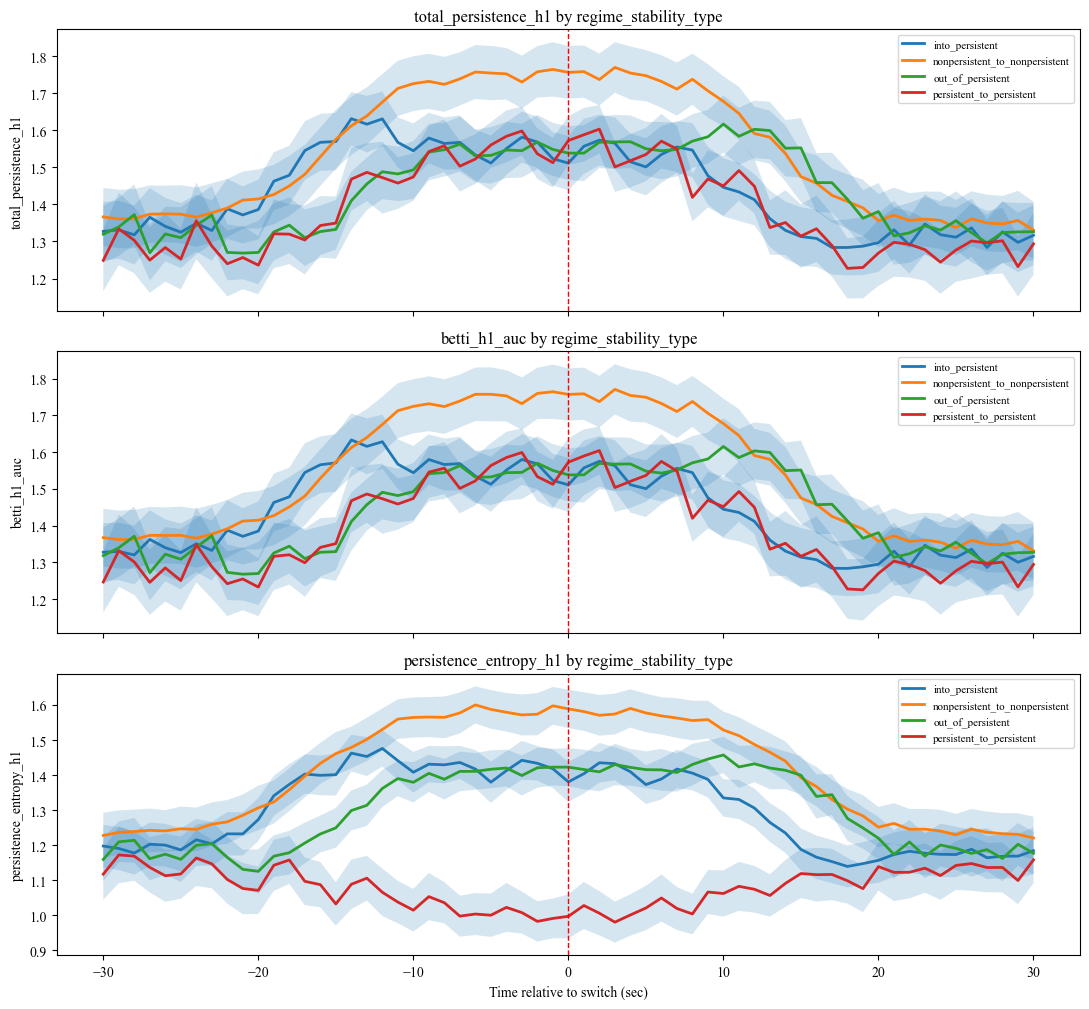

In [24]:
if df_main.empty:
    print("No analysis table available yet.")
else:
    df_real = df_main[df_main["anchor_kind"] == "real"].copy()
    display(df_real.head(3) if not df_real.empty else pd.DataFrame())

    if not df_real.empty:
        _ = plot_timecourse_grid(
            df_real,
            TOPO_FEATURES,
            group_col="jump_magnitude_bin",
            out_name="moderator_jump_magnitude_timecourses_real_only",
            min_sessions=8,
        )
        _ = plot_timecourse_grid(
            df_real,
            TOPO_FEATURES,
            group_col="regime_stability_type",
            out_name="moderator_regime_stability_timecourses_real_only",
            min_sessions=8,
        )

## 9. Moderator Time Courses: Client and Therapist Valence Direction

We now produce **two time-course plot sets**:
1. client valence direction
2. therapist valence direction

- transitions with little or no valence movement are labeled as **neutral_or_minimal_change**

Client valence direction counts:


,client_valence_direction,n_switches
0,neutral_or_minimal_change,55392
1,toward_more_negative,11102
2,toward_neutral_or_positive,11066


Therapist valence direction counts:


,therapist_valence_direction,n_switches
0,neutral_or_minimal_change,42700
1,toward_more_negative,17614
2,toward_neutral_or_positive,17246


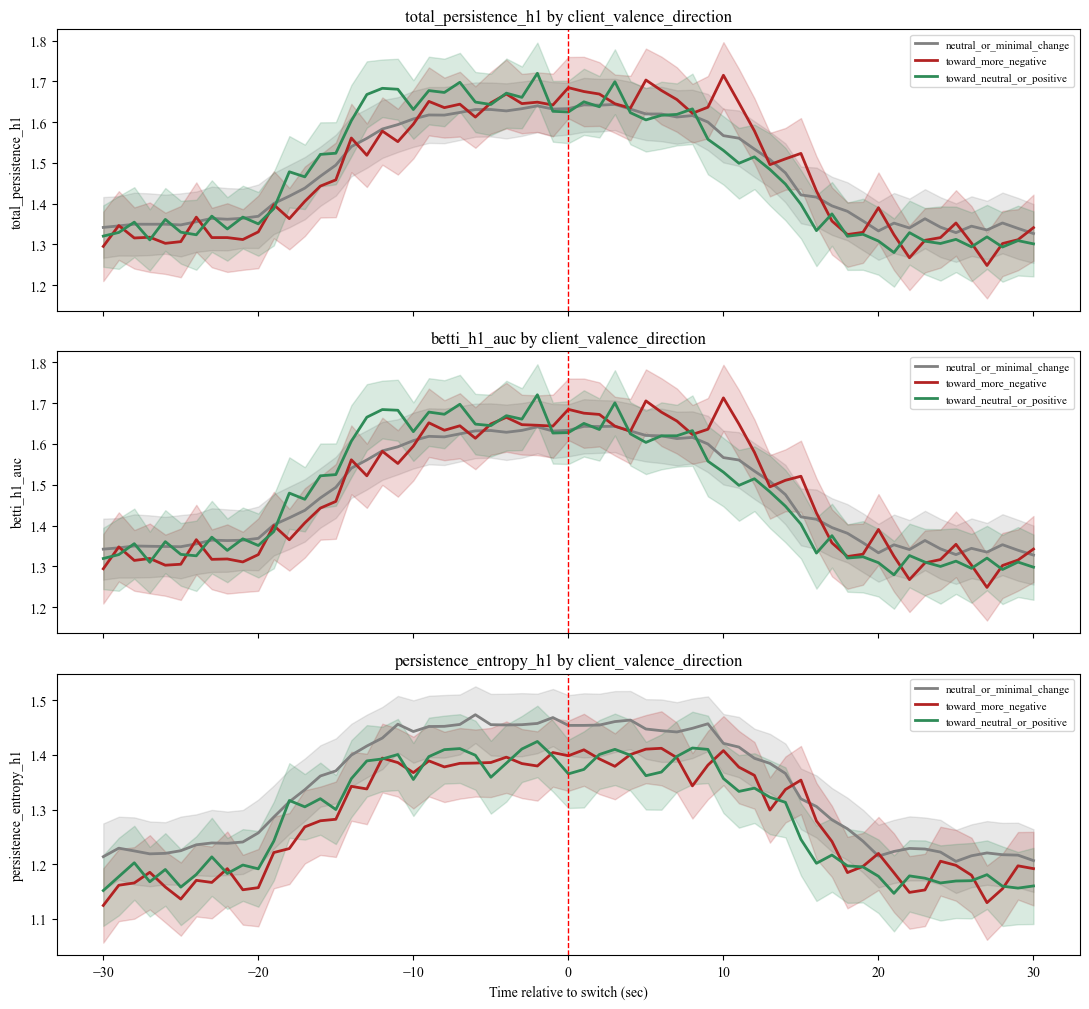

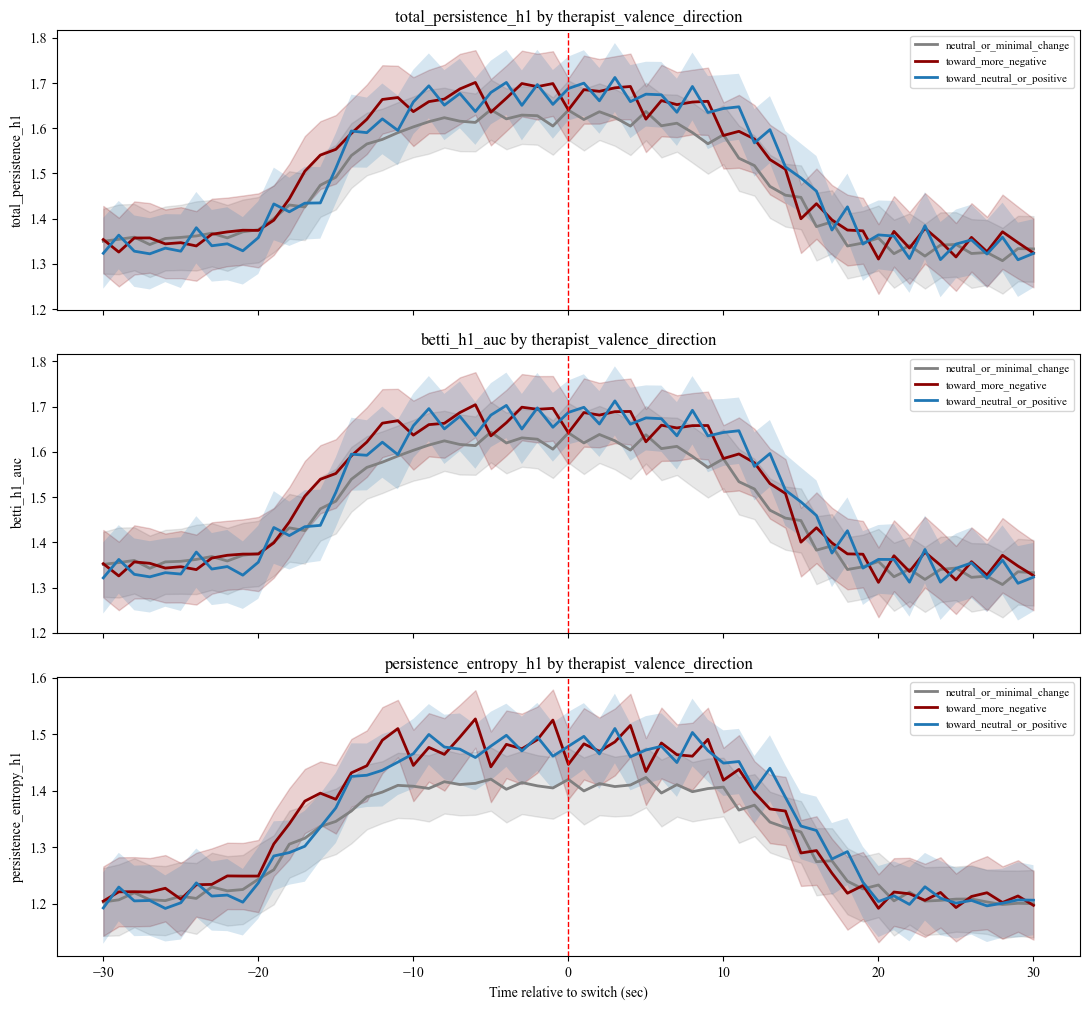

,client_valence_direction,rel_time_sec,mean,sd,n,sem,lower,upper,feature
0,neutral_or_minimal_change,-30.0,1.341608,0.438252,133,0.038001,1.267125,1.416090,total_persistence_h1
1,neutral_or_minimal_change,-29.0,1.345326,0.428096,133,0.037121,1.272570,1.418083,total_persistence_h1
2,neutral_or_minimal_change,-28.0,1.349438,0.454315,133,0.039394,1.272226,1.426651,total_persistence_h1
3,neutral_or_minimal_change,-27.0,1.349385,0.445365,133,0.038618,1.273694,1.425077,total_persistence_h1
4,neutral_or_minimal_change,-26.0,1.349425,0.426194,133,0.036956,1.276992,1.421858,total_persistence_h1
5,neutral_or_minimal_change,-25.0,1.347747,0.455228,133,0.039473,1.270379,1.425114,total_persistence_h1
6,neutral_or_minimal_change,-24.0,1.355505,0.435737,133,0.037783,1.281450,1.429560,total_persistence_h1
7,neutral_or_minimal_change,-23.0,1.363716,0.458418,133,0.039750,1.285806,1.441626,total_persistence_h1
8,neutral_or_minimal_change,-22.0,1.361637,0.449600,133,0.038985,1.285226,1.438048,total_persistence_h1
9,neutral_or_minimal_change,-21.0,1.364051,0.427039,133,0.037029,1.291474,1.436628,total_persistence_h1


,therapist_valence_direction,rel_time_sec,mean,sd,n,sem,lower,upper,feature
0,neutral_or_minimal_change,-30.0,1.350064,0.421848,133,0.036579,1.278370,1.421759,total_persistence_h1
1,neutral_or_minimal_change,-29.0,1.354245,0.453567,133,0.039329,1.277160,1.431331,total_persistence_h1
2,neutral_or_minimal_change,-28.0,1.359075,0.432003,133,0.037459,1.285654,1.432495,total_persistence_h1
3,neutral_or_minimal_change,-27.0,1.342704,0.423472,133,0.036720,1.270734,1.414675,total_persistence_h1
4,neutral_or_minimal_change,-26.0,1.356152,0.416313,133,0.036099,1.285399,1.426906,total_persistence_h1
5,neutral_or_minimal_change,-25.0,1.358516,0.423850,133,0.036752,1.286481,1.430551,total_persistence_h1
6,neutral_or_minimal_change,-24.0,1.361731,0.450181,133,0.039036,1.285221,1.438241,total_persistence_h1
7,neutral_or_minimal_change,-23.0,1.367784,0.432151,133,0.037472,1.294338,1.441229,total_persistence_h1
8,neutral_or_minimal_change,-22.0,1.357481,0.429134,133,0.037211,1.284548,1.430414,total_persistence_h1
9,neutral_or_minimal_change,-21.0,1.370876,0.419336,133,0.036361,1.299609,1.442144,total_persistence_h1


In [30]:
if df_main.empty:
    print("No analysis table available yet.")
else:
    df_real = df_main[df_main["anchor_kind"] == "real"].copy()
    if df_real.empty:
        print("No real-switch rows available.")
    else:
        print("Client valence direction counts:")
        display(
            df_real[["session_id", "switch_index", "client_valence_direction"]]
            .drop_duplicates()["client_valence_direction"]
            .value_counts()
            .rename_axis("client_valence_direction")
            .reset_index(name="n_switches")
        )

        print("Therapist valence direction counts:")
        display(
            df_real[["session_id", "switch_index", "therapist_valence_direction"]]
            .drop_duplicates()["therapist_valence_direction"]
            .value_counts()
            .rename_axis("therapist_valence_direction")
            .reset_index(name="n_switches")
        )

        client_palette = {
            "toward_more_negative": "firebrick",
            "toward_neutral_or_positive": "seagreen",
            "neutral_or_minimal_change": "gray",
        }

        therapist_palette = {
            "toward_more_negative": "darkred",
            "toward_more_neutral": "peru",
            "toward_more_positive": "darkgreen",
            "neutral_or_minimal_change": "gray",
        }

        df_client_valence_sum = plot_timecourse_grid(
            df_real,
            TOPO_FEATURES,
            group_col="client_valence_direction",
            out_name="moderator_client_valence_direction_timecourses_real_only",
            min_sessions=8,
            palette=client_palette,
        )

        df_therapist_valence_sum = plot_timecourse_grid(
            df_real,
            TOPO_FEATURES,
            group_col="therapist_valence_direction",
            out_name="moderator_therapist_valence_direction_timecourses_real_only",
            min_sessions=8,
            palette=therapist_palette,
        )

        display(df_client_valence_sum.head(10) if not df_client_valence_sum.empty else pd.DataFrame())
        display(df_therapist_valence_sum.head(10) if not df_therapist_valence_sum.empty else pd.DataFrame())

Client valence direction counts:


,client_valence_direction,n_switches
0,neutral_or_minimal_change,55392
1,toward_more_negative,11102
2,toward_neutral_or_positive,11066


Therapist valence direction counts:


,therapist_valence_direction,n_switches
0,neutral_or_minimal_change,42700
1,toward_more_negative,17614
2,toward_neutral_or_positive,17246


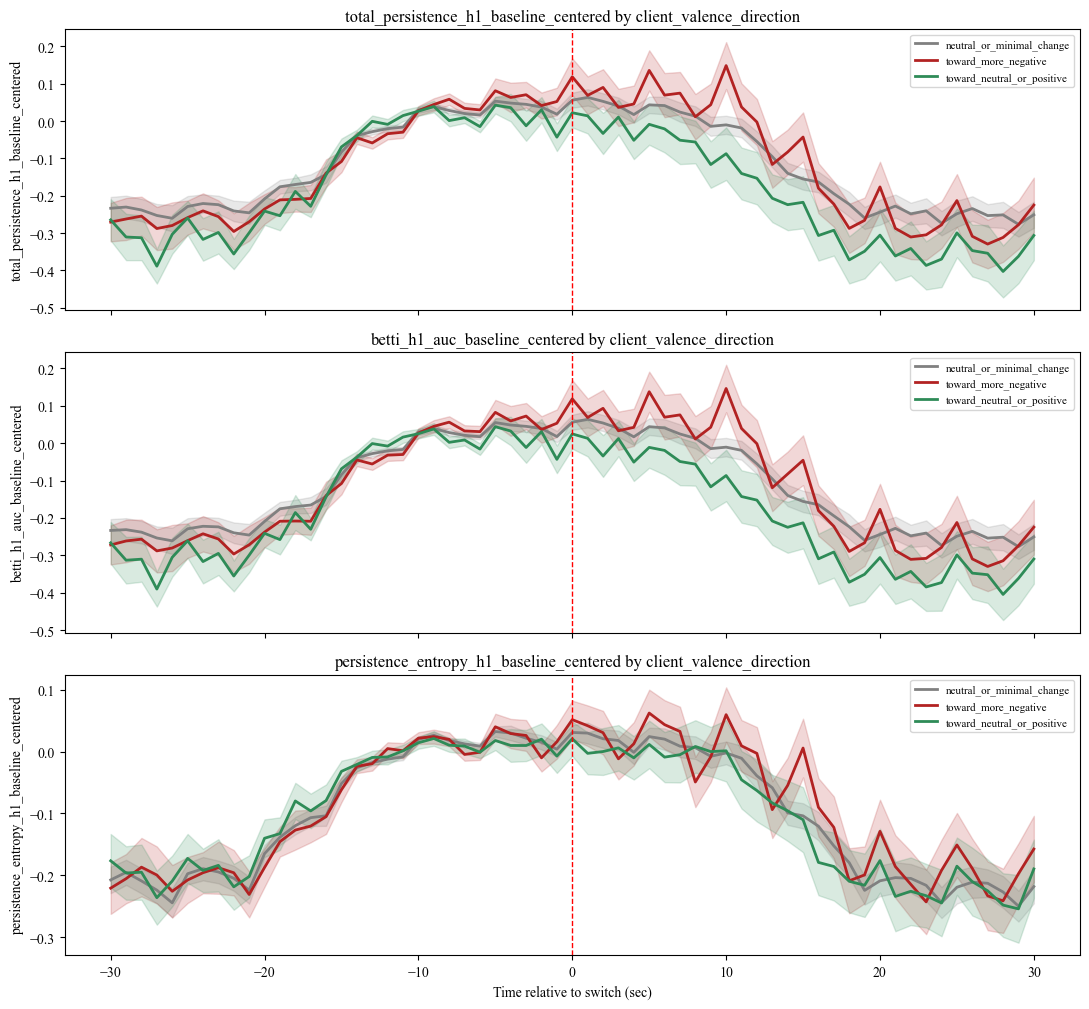

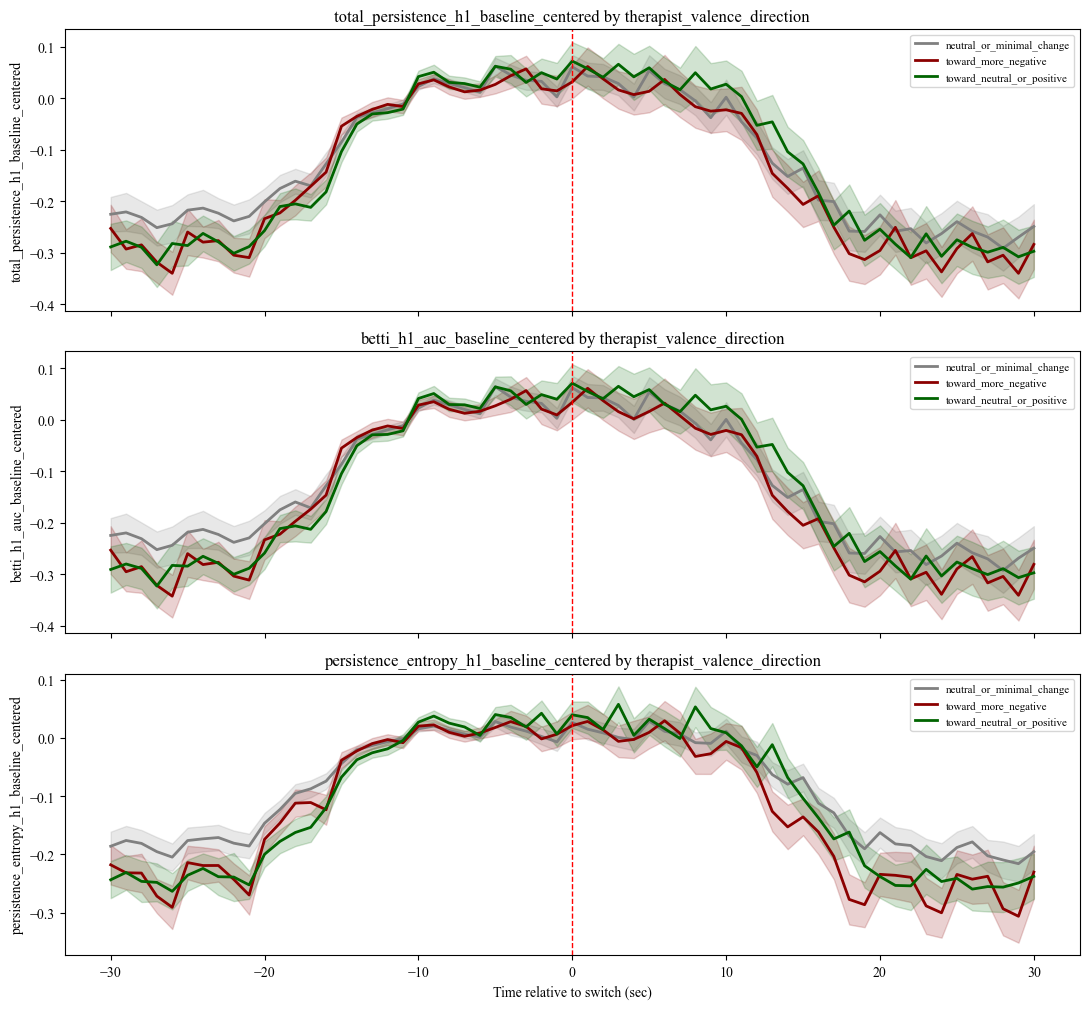

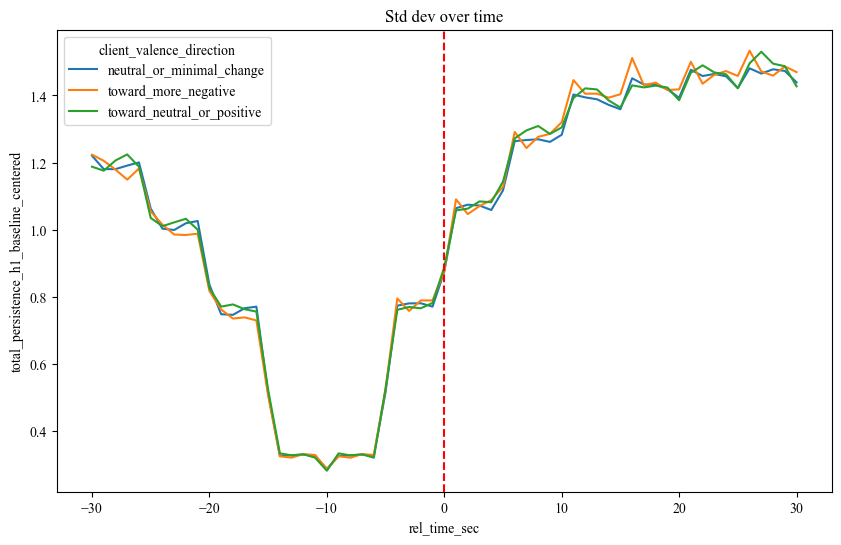

,client_valence_direction,rel_time_sec,mean,sd,n,sem,lower,upper,feature
0,neutral_or_minimal_change,-30.0,-0.233599,0.178045,133,0.015438,-0.263859,-0.203340,total_persistence_h1_baseline_centered
1,neutral_or_minimal_change,-29.0,-0.230382,0.179686,133,0.015581,-0.260920,-0.199844,total_persistence_h1_baseline_centered
2,neutral_or_minimal_change,-28.0,-0.238273,0.175840,133,0.015247,-0.268158,-0.208389,total_persistence_h1_baseline_centered
3,neutral_or_minimal_change,-27.0,-0.252946,0.180210,133,0.015626,-0.283573,-0.222318,total_persistence_h1_baseline_centered
4,neutral_or_minimal_change,-26.0,-0.260451,0.206956,133,0.017945,-0.295624,-0.225278,total_persistence_h1_baseline_centered
5,neutral_or_minimal_change,-25.0,-0.228901,0.164875,133,0.014296,-0.256922,-0.200880,total_persistence_h1_baseline_centered
6,neutral_or_minimal_change,-24.0,-0.220899,0.143147,133,0.012412,-0.245227,-0.196570,total_persistence_h1_baseline_centered
7,neutral_or_minimal_change,-23.0,-0.224062,0.141996,133,0.012313,-0.248195,-0.199929,total_persistence_h1_baseline_centered
8,neutral_or_minimal_change,-22.0,-0.240764,0.161522,133,0.014006,-0.268215,-0.213312,total_persistence_h1_baseline_centered
9,neutral_or_minimal_change,-21.0,-0.245899,0.175428,133,0.015212,-0.275714,-0.216084,total_persistence_h1_baseline_centered


,therapist_valence_direction,rel_time_sec,mean,sd,n,sem,lower,upper,feature
0,neutral_or_minimal_change,-30.0,-0.225588,0.197917,133,0.017162,-0.259225,-0.191952,total_persistence_h1_baseline_centered
1,neutral_or_minimal_change,-29.0,-0.221060,0.217216,133,0.018835,-0.257976,-0.184143,total_persistence_h1_baseline_centered
2,neutral_or_minimal_change,-28.0,-0.231703,0.184398,133,0.015989,-0.263042,-0.200363,total_persistence_h1_baseline_centered
3,neutral_or_minimal_change,-27.0,-0.251626,0.205346,133,0.017806,-0.286525,-0.216727,total_persistence_h1_baseline_centered
4,neutral_or_minimal_change,-26.0,-0.244096,0.214070,133,0.018562,-0.280478,-0.207714,total_persistence_h1_baseline_centered
5,neutral_or_minimal_change,-25.0,-0.217651,0.180715,133,0.015670,-0.248365,-0.186938,total_persistence_h1_baseline_centered
6,neutral_or_minimal_change,-24.0,-0.213689,0.209204,133,0.018140,-0.249243,-0.178134,total_persistence_h1_baseline_centered
7,neutral_or_minimal_change,-23.0,-0.223565,0.171584,133,0.014878,-0.252726,-0.194403,total_persistence_h1_baseline_centered
8,neutral_or_minimal_change,-22.0,-0.238566,0.186742,133,0.016193,-0.270303,-0.206828,total_persistence_h1_baseline_centered
9,neutral_or_minimal_change,-21.0,-0.229757,0.195090,133,0.016916,-0.262913,-0.196601,total_persistence_h1_baseline_centered


In [36]:
if df_main.empty:
    print("No analysis table available yet.")
else:
    df_real = df_main[df_main["anchor_kind"] == "real"].copy()
    if df_real.empty:
        print("No real-switch rows available.")
    else:
        print("Client valence direction counts:")
        display(
            df_real[["session_id", "switch_index", "client_valence_direction"]]
            .drop_duplicates()["client_valence_direction"]
            .value_counts()
            .rename_axis("client_valence_direction")
            .reset_index(name="n_switches")
        )

        print("Therapist valence direction counts:")
        display(
            df_real[["session_id", "switch_index", "therapist_valence_direction"]]
            .drop_duplicates()["therapist_valence_direction"]
            .value_counts()
            .rename_axis("therapist_valence_direction")
            .reset_index(name="n_switches")
        )

        client_palette = {
            "toward_more_negative": "firebrick",
            "toward_neutral_or_positive": "seagreen",
            "neutral_or_minimal_change": "gray",
        }

        therapist_palette = {
            "toward_more_negative": "darkred",
            "toward_neutral_or_positive": "darkgreen",
            "neutral_or_minimal_change": "gray",
        }

        delta_features = [
            "total_persistence_h1_baseline_centered",
            "betti_h1_auc_baseline_centered",
            "persistence_entropy_h1_baseline_centered",
        ]

        df_client_valence_sum = plot_timecourse_grid(
            df_real,
            delta_features,
            group_col="client_valence_direction",
            out_name="moderator_client_valence_direction_timecourses_real_only_baselined",
            min_sessions=8,
            palette=client_palette,
        )

        df_therapist_valence_sum = plot_timecourse_grid(
            df_real,
            delta_features,
            group_col="therapist_valence_direction",
            out_name="moderator_therapist_valence_direction_timecourses_real_only_baselined",
            min_sessions=8,
            palette=therapist_palette,
        )

        std_df = (
            df_real
            .groupby(["client_valence_direction", "rel_time_sec"])["total_persistence_h1_baseline_centered"]
            .std()
            .reset_index()
        )

        sns.lineplot(data=std_df, x="rel_time_sec", y="total_persistence_h1_baseline_centered", hue="client_valence_direction")
        plt.axvline(0, linestyle="--", color="red")
        plt.title("Std dev over time")
        plt.show()

        display(df_client_valence_sum.head(10) if not df_client_valence_sum.empty else pd.DataFrame())
        display(df_therapist_valence_sum.head(10) if not df_therapist_valence_sum.empty else pd.DataFrame())

## 10. Transition Identity Reorganization (Exploratory)

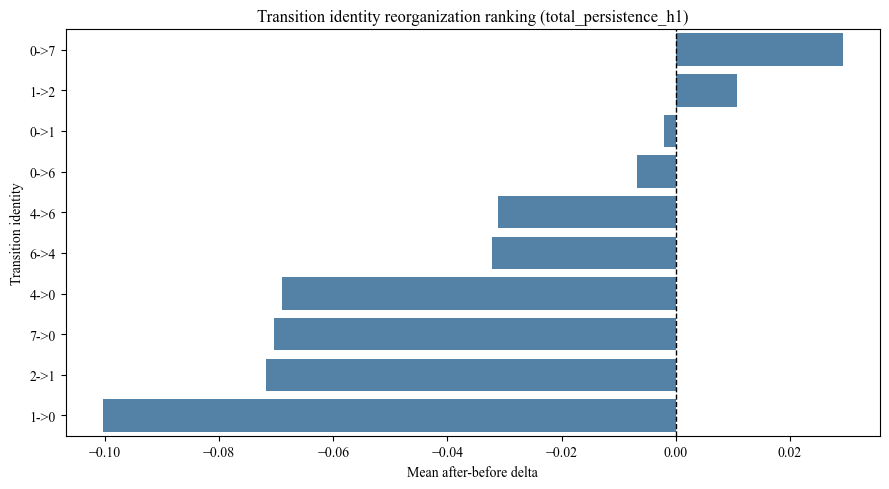

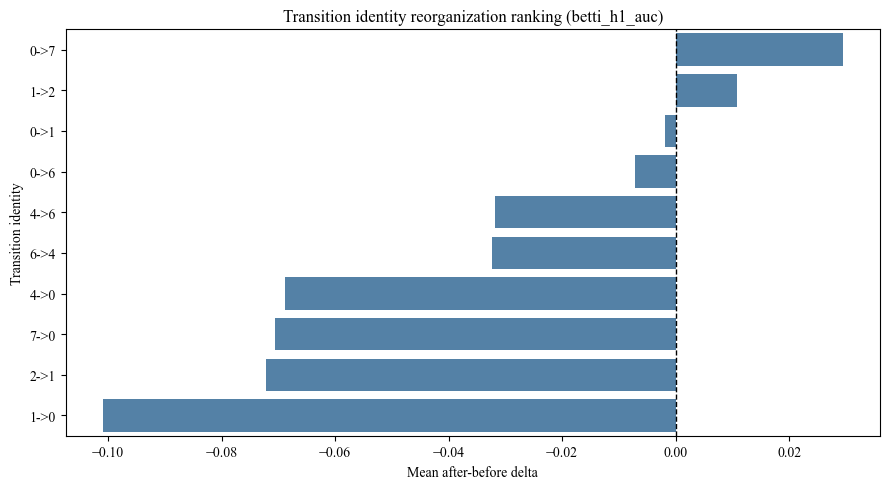

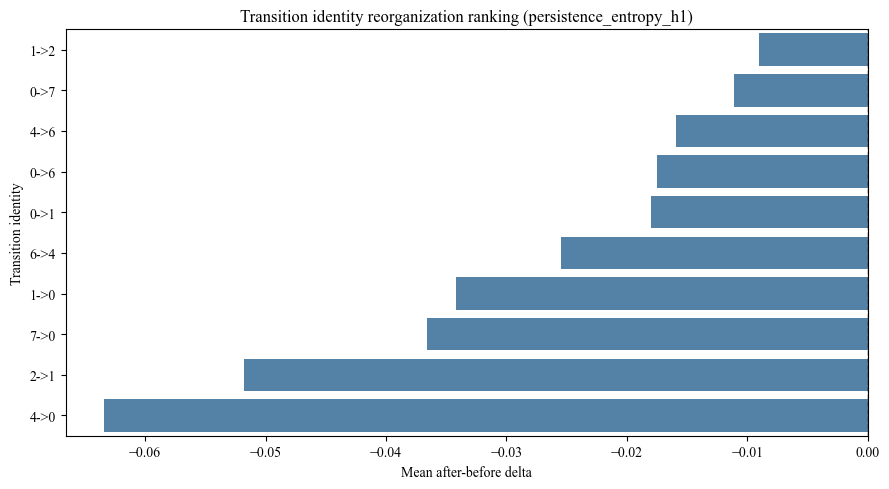

,transition_identity,mean_delta,median_delta,n_switches,feature
0,0->1,-0.002072,-0.000076,5793,total_persistence_h1
1,0->2,0.094500,0.075190,415,total_persistence_h1
2,0->3,0.019250,0.072370,197,total_persistence_h1
3,0->4,0.773343,0.773343,1,total_persistence_h1
4,0->5,0.080836,0.034810,69,total_persistence_h1
5,0->6,-0.006759,0.001007,6664,total_persistence_h1
6,0->7,0.029323,0.030138,2878,total_persistence_h1
7,1->0,-0.100422,-0.111274,5935,total_persistence_h1
8,1->2,0.010754,-0.001217,2785,total_persistence_h1
9,1->3,0.026071,0.018564,1362,total_persistence_h1


In [27]:
if df_main.empty:
    print("No analysis table available yet.")
else:
    rows = []
    top_identity_keep = None

    for f in TOPO_FEATURES:
        d = df_main[df_main["anchor_kind"] == "real"][["session_id", "switch_index", "transition_identity", "phase", f]].dropna().copy()
        if d.empty:
            continue

        sw = d.groupby(["session_id", "switch_index", "transition_identity", "phase"], as_index=False)[f].mean()
        wide = sw.pivot_table(index=["session_id", "switch_index", "transition_identity"], columns="phase", values=f).reset_index()
        if "before" not in wide.columns or "after" not in wide.columns:
            continue

        wide["delta_after_minus_before"] = wide["after"] - wide["before"]
        agg = (
            wide.groupby("transition_identity")["delta_after_minus_before"]
            .agg(mean_delta="mean", median_delta="median", n_switches="count")
            .reset_index()
        )
        agg["feature"] = f

        if top_identity_keep is None:
            top_identity_keep = (
                agg.sort_values("n_switches", ascending=False)
                .head(10)["transition_identity"]
                .tolist()
            )
        rows.append(agg)

        plot_df = agg[agg["transition_identity"].isin(top_identity_keep)].sort_values("mean_delta", ascending=False)
        if plot_df.empty:
            continue

        plt.figure(figsize=(9, 5))
        sns.barplot(data=plot_df, x="mean_delta", y="transition_identity", color="steelblue")
        plt.axvline(0.0, color="black", linestyle="--", linewidth=1.0)
        plt.title(f"Transition identity reorganization ranking ({f})")
        plt.xlabel("Mean after-before delta")
        plt.ylabel("Transition identity")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"transition_identity_delta_rank_{f}.svg", format="svg")
        plt.show()

    df_transition_rank = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    display(df_transition_rank.head(20) if not df_transition_rank.empty else pd.DataFrame())
    if not df_transition_rank.empty:
        df_transition_rank.to_csv(TAB_DIR / "transition_identity_reorganization_rankings.csv", index=False)


## 11. Compact Results Index

In [28]:
results_index = {
    "tables": {
        "primary_timecourse_summary": str(TAB_DIR / "primary_real_vs_pseudo_timecourses_summary.csv"),
        "primary_time_x_anchor_model_summary": str(TAB_DIR / "primary_time_x_anchor_model_summary.csv"),
        "difference_curves": str(TAB_DIR / "primary_real_minus_pseudo_difference_curves.csv"),
        "windowed_timecourse_summary": str(TAB_DIR / "windowed_timecourse_summary.csv"),
        "phase_contrast_and_jump_stats": str(TAB_DIR / "phase_contrast_and_jump_stats.csv"),
        "jump_magnitude_summary": str(TAB_DIR / "moderator_jump_magnitude_timecourses_real_only_summary.csv"),
        "regime_stability_summary": str(TAB_DIR / "moderator_regime_stability_timecourses_real_only_summary.csv"),
        "client_valence_summary": str(TAB_DIR / "moderator_client_valence_direction_timecourses_real_only_summary.csv"),
        "therapist_valence_summary": str(TAB_DIR / "moderator_therapist_valence_direction_timecourses_real_only_summary.csv"),
        "transition_identity_rankings": str(TAB_DIR / "transition_identity_reorganization_rankings.csv"),
    },
    "figures": {
        "qc_overview": str(FIG_DIR / "qc_overview.svg"),
        "primary_real_vs_pseudo_timecourses": str(FIG_DIR / "primary_real_vs_pseudo_timecourses.svg"),
        "primary_models_and_difference_curves": str(FIG_DIR / "primary_timecourse_models_and_difference_curves.svg"),
        "windowed_real_vs_pseudo_summary": str(FIG_DIR / "windowed_real_vs_pseudo_summary.svg"),
        "jump_magnitude_timecourses": str(FIG_DIR / "moderator_jump_magnitude_timecourses_real_only.svg"),
        "regime_stability_timecourses": str(FIG_DIR / "moderator_regime_stability_timecourses_real_only.svg"),
        "client_valence_timecourses": str(FIG_DIR / "moderator_client_valence_direction_timecourses_real_only.svg"),
        "therapist_valence_timecourses": str(FIG_DIR / "moderator_therapist_valence_direction_timecourses_real_only.svg"),
    },
}

(TAB_DIR / "notebook_results_index.json").write_text(json.dumps(results_index, indent=2))
print("Saved notebook results index to:", TAB_DIR / "notebook_results_index.json")


Saved notebook results index to: ../artifacts/regime_geometry/phase_transitions/notebook_tables/notebook_results_index.json
